# Speed benchmark

Visualizes `results/bench_speed.json` from `scripts/bench_speed.py`.
`baseline` = no optimizations at all (not even mask caching); each backend
row was structurally verified with `check_accel` before timing.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

RESULTS = Path("../results")
raw = json.loads((RESULTS / "bench_speed.json").read_text())
print(json.dumps(raw["meta"], indent=2))
df = pd.json_normalize(raw["records"])
df

{
  "model_id": "tiny-random-donut",
  "device": "cpu",
  "dtype": "float32",
  "torch": "2.12.0+cu130",
  "transformers": "5.9.0",
  "seed": 42,
  "timestamp": "2026-06-11T14:36:53+00:00",
  "git_sha": "e4c1981"
}


,backend,compile,batch_size,encoder.mean_ms,encoder.std_ms,encoder.p50_ms,encoder.p95_ms,encoder.n_runs,generate.mean_ms,generate.std_ms,generate.p50_ms,generate.p95_ms,generate.n_runs,throughput.images_per_s,throughput.tokens_per_s,speedup_vs_baseline.encoder,speedup_vs_baseline.generate
0,baseline,False,1,6.332,0.159,6.335,6.526,3,29.624,3.057,31.534,32.027,3,33.756,270.051,1.000,1.000
1,eager,False,1,5.174,0.616,4.796,6.042,3,31.518,7.150,28.730,41.330,3,31.728,253.823,1.224,0.940
2,sdpa,False,1,3.951,0.461,4.199,4.349,3,33.124,4.016,32.673,38.252,3,30.190,241.517,1.603,0.894


## Encoder latency per backend (p95 whiskers)

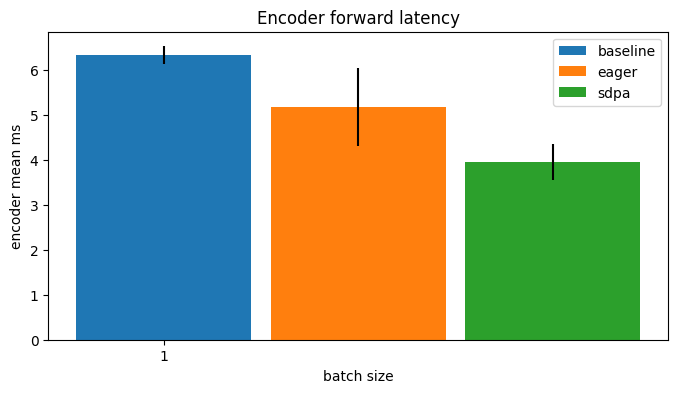

In [2]:
fig, ax = plt.subplots(figsize=(8, 4))
for i, (backend, g) in enumerate(df.groupby("backend", sort=False)):
    x = [j + i * 0.2 for j in range(len(g))]
    err = g["encoder.p95_ms"] - g["encoder.mean_ms"]
    ax.bar(x, g["encoder.mean_ms"], width=0.18, yerr=err.clip(lower=0), label=backend)
ax.set_xticks(range(df.batch_size.nunique()))
ax.set_xticklabels(sorted(df.batch_size.unique()))
ax.set_xlabel("batch size")
ax.set_ylabel("encoder mean ms")
ax.legend()
ax.set_title("Encoder forward latency")
plt.show()

## Generation throughput and speedup vs baseline

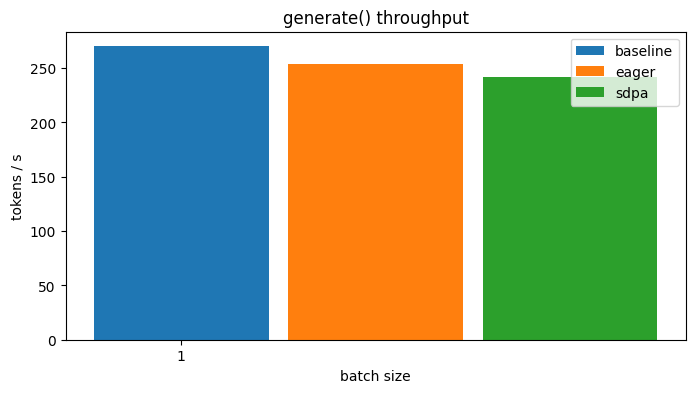

,speedup_vs_baseline.encoder,speedup_vs_baseline.generate
batch_size,1,1
backend,,
baseline,1.000,1.000
eager,1.224,0.940
sdpa,1.603,0.894


In [3]:
fig, ax = plt.subplots(figsize=(8, 4))
for i, (backend, g) in enumerate(df.groupby("backend", sort=False)):
    x = [j + i * 0.2 for j in range(len(g))]
    ax.bar(x, g["throughput.tokens_per_s"], width=0.18, label=backend)
ax.set_xticks(range(df.batch_size.nunique()))
ax.set_xticklabels(sorted(df.batch_size.unique()))
ax.set_xlabel("batch size")
ax.set_ylabel("tokens / s")
ax.legend()
ax.set_title("generate() throughput")
plt.show()

df.pivot_table(
    index="backend",
    columns="batch_size",
    values=["speedup_vs_baseline.encoder", "speedup_vs_baseline.generate"],
)

## Batch-size scaling

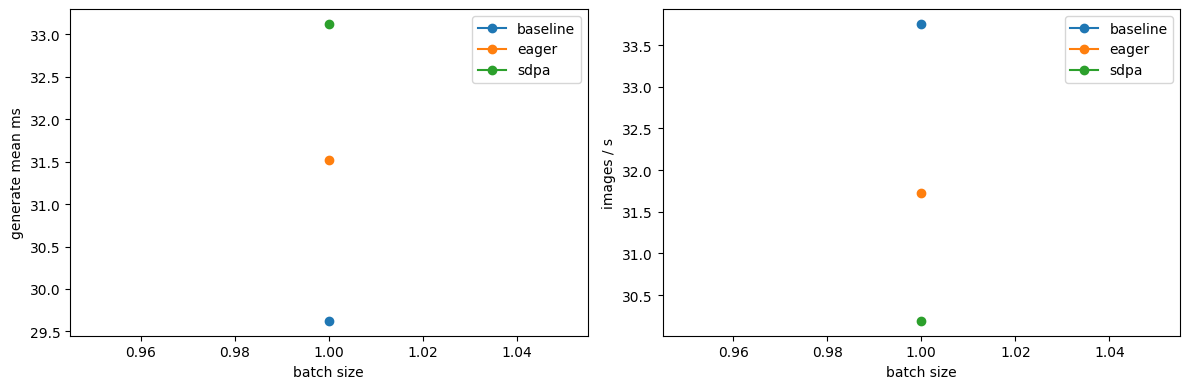

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for backend, g in df.groupby("backend", sort=False):
    g = g.sort_values("batch_size")
    axes[0].plot(g.batch_size, g["generate.mean_ms"], marker="o", label=backend)
    axes[1].plot(g.batch_size, g["throughput.images_per_s"], marker="o", label=backend)
axes[0].set_ylabel("generate mean ms")
axes[1].set_ylabel("images / s")
for ax in axes:
    ax.set_xlabel("batch size")
    ax.legend()
plt.tight_layout()
plt.show()

## Notes

- CPU numbers are noisy and only useful as smoke checks; trust CUDA runs with
  `n_runs >= 10`.
- Adding a new backend: add a preset in `donut/accel/__init__.py`, then
  `--backends eager,sdpa,<new>` — the JSON schema and this notebook pick it
  up unchanged.